# Top 10 States Sales Analysis
This notebook analyzes geographic sales performance, focusing on the top-performing states by revenue.
We'll clean the data, create visualizations, and extract insights about regional sales patterns.

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from matplotlib.ticker import FuncFormatter

## 1. Data Preparation
Loading the raw Amazon sales dataset.

In [5]:
df = pd.read_csv('../data/amazon_sale_report.csv', low_memory=False)

df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 128975 entries, 0 to 128974
Data columns (total 24 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   index               128975 non-null  int64  
 1   Order ID            128975 non-null  str    
 2   Date                128975 non-null  str    
 3   Status              128975 non-null  str    
 4   Fulfilment          128975 non-null  str    
 5   Sales Channel       128975 non-null  str    
 6   ship-service-level  128975 non-null  str    
 7   Style               128975 non-null  str    
 8   SKU                 128975 non-null  str    
 9   Category            128975 non-null  str    
 10  Size                128975 non-null  str    
 11  ASIN                128975 non-null  str    
 12  Courier Status      122103 non-null  str    
 13  Qty                 128975 non-null  int64  
 14  currency            121180 non-null  str    
 15  Amount              121180 non-null  float64


,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
0,0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,...,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship,NaN
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,...,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,...,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN
3,3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,...,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,NaN,False,Easy Ship,NaN
4,4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,...,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,NaN,False,NaN,NaN


## 2. Feature Selection
Selecting relevant columns for geographic sales analysis and creating a focused dataset.

In [6]:
# Keep only the relevant columns
columns_to_keep = [
    'Date', 
    'Status', 
    'Fulfilment', 
    'Sales Channel ',
    'Qty',
    'Amount', 
    'ship-city', 
    'ship-state', 
    'ship-postal-code', 
    'ship-country'
]

geo_sales_df = df[columns_to_keep].copy()

geo_sales_df.info()
geo_sales_df.head()

<class 'pandas.DataFrame'>
RangeIndex: 128975 entries, 0 to 128974
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Date              128975 non-null  str    
 1   Status            128975 non-null  str    
 2   Fulfilment        128975 non-null  str    
 3   Sales Channel     128975 non-null  str    
 4   Qty               128975 non-null  int64  
 5   Amount            121180 non-null  float64
 6   ship-city         128942 non-null  str    
 7   ship-state        128942 non-null  str    
 8   ship-postal-code  128942 non-null  float64
 9   ship-country      128942 non-null  str    
dtypes: float64(2), int64(1), str(7)
memory usage: 9.8 MB


,Date,Status,Fulfilment,Sales Channel,Qty,Amount,ship-city,ship-state,ship-postal-code,ship-country
0,04-30-22,Cancelled,Merchant,Amazon.in,0,647.62,MUMBAI,MAHARASHTRA,400081.0,IN
1,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,1,406.00,BENGALURU,KARNATAKA,560085.0,IN
2,04-30-22,Shipped,Amazon,Amazon.in,1,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN
3,04-30-22,Cancelled,Merchant,Amazon.in,0,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN
4,04-30-22,Shipped,Amazon,Amazon.in,1,574.00,CHENNAI,TAMIL NADU,600073.0,IN


## 3. Data Preprocessing
Cleaning and preparing the dataset for analysis by handling data quality issues and standardizing formats.
- Standardize column names by removing whitespace
- Filter out cancelled orders and non-transactional records
- Remove records with missing values in critical fields
- Convert Date column to proper datetime format for time-based analysis
- Standardize Postal Code as numeric type for geographic analysis
- Clean and normalize text fields (state names, city names, country codes)
- Ensure consistent data types across all columns for analysis readiness

In [7]:
# Remove whitespace from column names
df.columns = df.columns.str.strip()

# Filter for actual shipped orders
shipped_statuses = [
    'Shipped',
    'Shipped - Delivered to Buyer',
    'Shipped - Picked Up',
    'Shipped - Out for Delivery'
]

is_shipped = geo_sales_df['Status'].isin(shipped_statuses)
geo_sales_df = geo_sales_df[is_shipped].copy()

# Remove rows with missing values in fields used for analysis and formatting
geo_sales_df.dropna(
    subset=['Amount', 'ship-city', 'ship-state', 'ship-country', 'ship-postal-code'],
    inplace=True
)

# Convert Date from string to proper datetime object
geo_sales_df['Date'] = pd.to_datetime(geo_sales_df['Date'], format='%m-%d-%y')

# Convert postal code to integer first (to remove .0) and then string
geo_sales_df['ship-postal-code'] = geo_sales_df['ship-postal-code'].astype(int).astype(str)

# Clean up the city, state, and country names
geo_sales_df['ship-state'] = geo_sales_df['ship-state'].str.strip()
geo_sales_df['ship-city'] = geo_sales_df['ship-city'].str.strip()
geo_sales_df['ship-country'] = geo_sales_df['ship-country'].str.strip()

# Standardize text formatting
geo_sales_df['ship-state'] = geo_sales_df['ship-state'].str.title()
geo_sales_df['ship-city'] = geo_sales_df['ship-city'].str.title()
geo_sales_df['ship-country'] = geo_sales_df['ship-country'].str.upper()

geo_sales_df.info()
geo_sales_df.head()

<class 'pandas.DataFrame'>
Index: 107342 entries, 1 to 128974
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Date              107342 non-null  datetime64[us]
 1   Status            107342 non-null  str           
 2   Fulfilment        107342 non-null  str           
 3   Sales Channel     107342 non-null  str           
 4   Qty               107342 non-null  int64         
 5   Amount            107342 non-null  float64       
 6   ship-city         107342 non-null  str           
 7   ship-state        107342 non-null  str           
 8   ship-postal-code  107342 non-null  str           
 9   ship-country      107342 non-null  str           
dtypes: datetime64[us](1), float64(1), int64(1), str(7)
memory usage: 9.0 MB


,Date,Status,Fulfilment,Sales Channel,Qty,Amount,ship-city,ship-state,ship-postal-code,ship-country
1,2022-04-30,Shipped - Delivered to Buyer,Merchant,Amazon.in,1,406.0,Bengaluru,Karnataka,560085,IN
2,2022-04-30,Shipped,Amazon,Amazon.in,1,329.0,Navi Mumbai,Maharashtra,410210,IN
4,2022-04-30,Shipped,Amazon,Amazon.in,1,574.0,Chennai,Tamil Nadu,600073,IN
5,2022-04-30,Shipped,Amazon,Amazon.in,1,824.0,Ghaziabad,Uttar Pradesh,201102,IN
6,2022-04-30,Shipped,Amazon,Amazon.in,1,653.0,Chandigarh,Chandigarh,160036,IN


## 4. Top 10 States by Sales Revenue
Creating comprehensive visualizations of the top-performing states across multiple currencies.

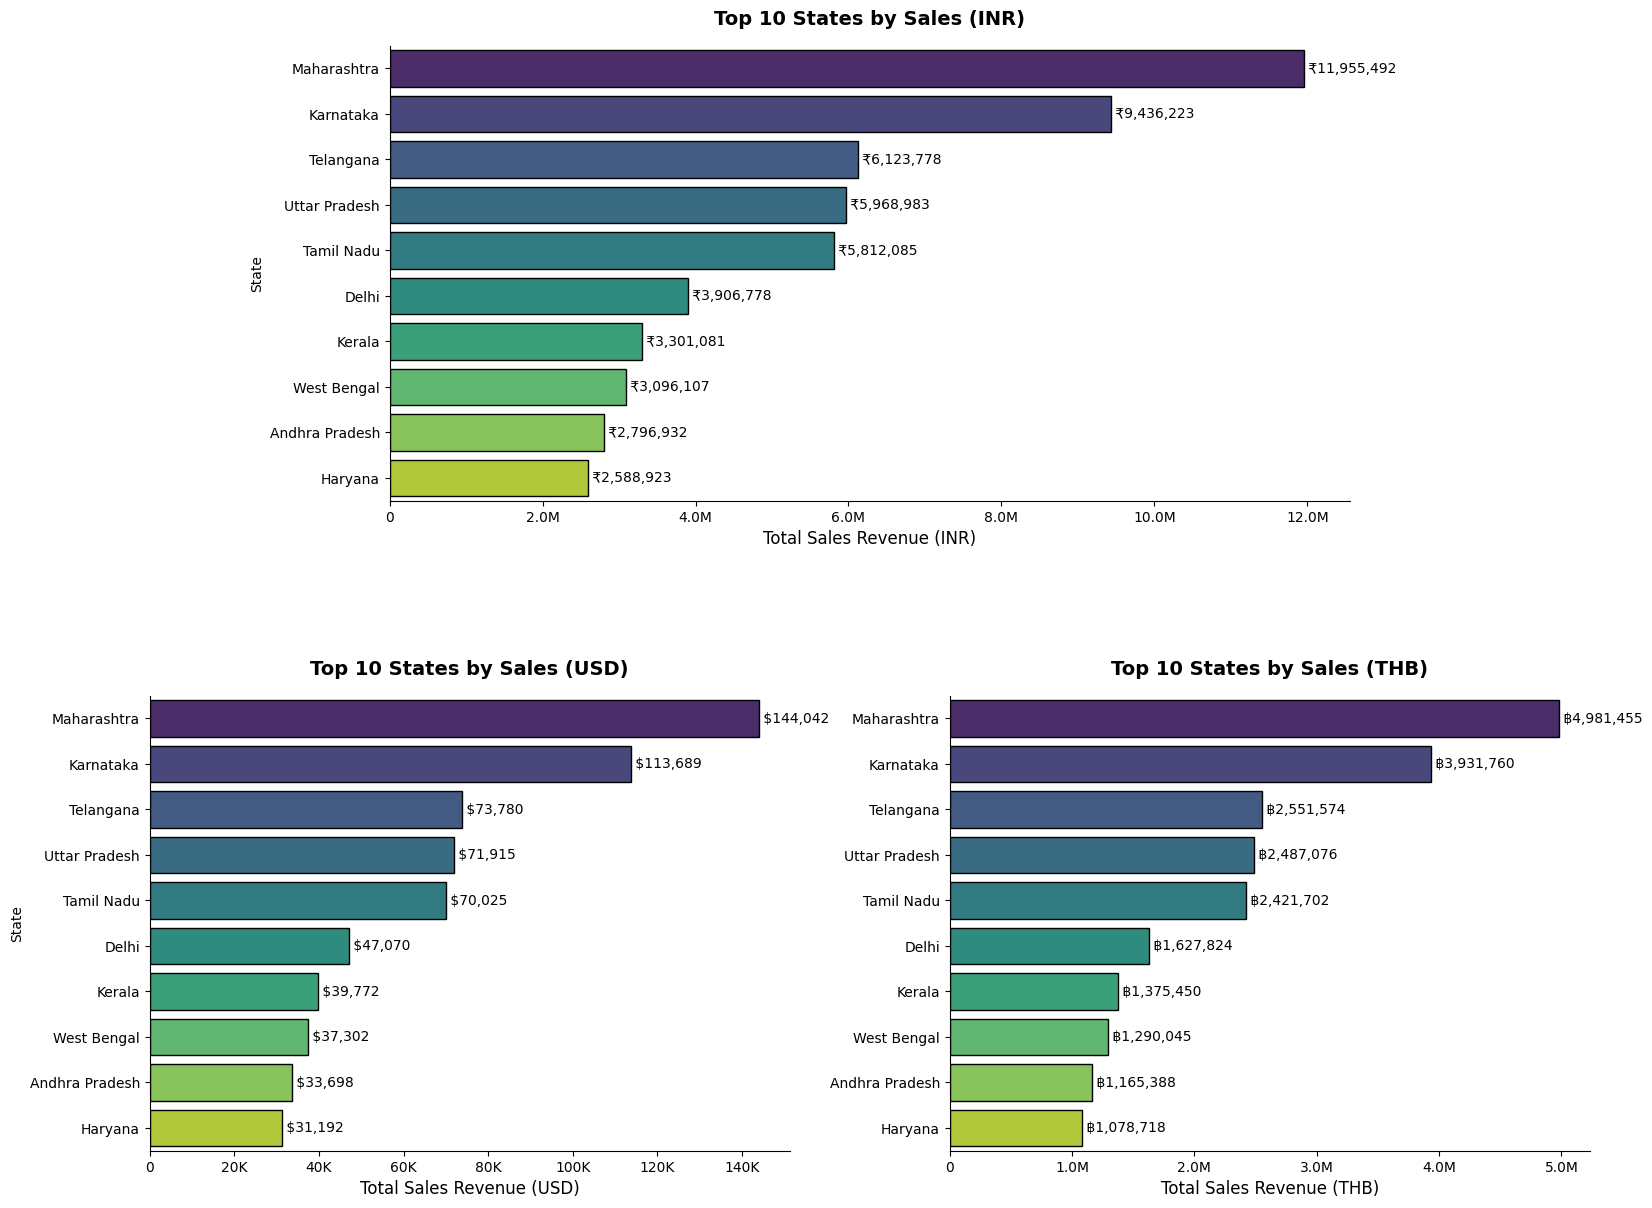

In [8]:
# Money formatter
def money_format(x, pos):
    if x >= 1_000_000:
        return f"{x/1_000_000:.1f}M"
    elif x >= 1_000:
        return f"{x/1_000:.0f}K"
    else:
        return f"{x:.0f}"

formatter = FuncFormatter(money_format)

# Prepare data
state_sales = (
    geo_sales_df.groupby("ship-state")["Amount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

# Create triangular layout with three subplots for multi-currency comparison
fig = plt.figure(figsize=(16, 13))

ax1 = fig.add_axes([0.2, 0.55, 0.6, 0.35])   # top center
ax2 = fig.add_axes([0.05, 0.05, 0.4, 0.35])  # bottom left
ax3 = fig.add_axes([0.55, 0.05, 0.4, 0.35])  # bottom right

axes = [ax1, ax2, ax3]

# Currency configs
currencies = [
    ('INR', 1.0, '₹'),
    ('USD', 1/83.0, '$'),
    ('THB', 1/2.4, '฿')
]

# Plot loop
for ax, (curr, rate, symbol) in zip(axes, currencies):
    sales = state_sales * rate

    sns.barplot(
        x=sales.values,
        y=sales.index,
        ax=ax,
        hue=sales.index,
        legend=False,
        palette='viridis',
        edgecolor='black'
    )

    # Titles & labels
    ax.set_title(f'Top 10 States by Sales ({curr})', fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel(f'Total Sales Revenue ({curr})', fontsize=12)
    ax.set_ylabel('State' if ax in [ax1, ax2] else '')

    # Use your formatter (FIXED)
    ax.xaxis.set_major_formatter(formatter)

    # Value labels
    for i, v in enumerate(sales.values):
        ax.text(v, i, f' {symbol}{v:,.0f}', va='center', fontsize=10)

    # Clean spines
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# Save the figure
plt.savefig('../images/01_top10_states_sales/top10_states_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## 5. Fulfillment Method Performance by State
Analyzing the distribution and performance of Amazon vs Merchant fulfillment across top states.

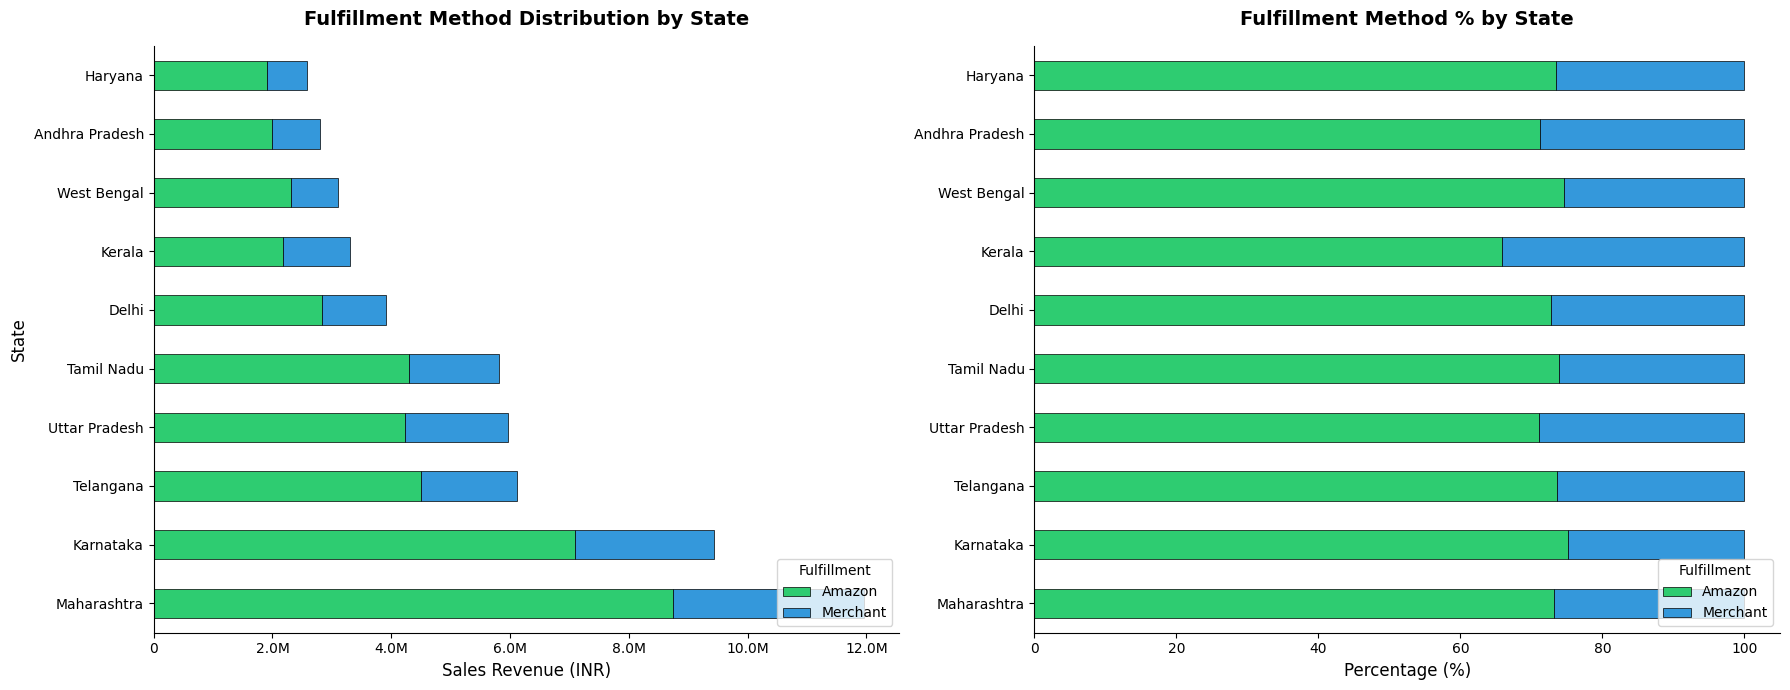


FULFILLMENT METHOD INSIGHTS
Maharashtra - Amazon: 73.1% (₹8,743,630)
Maharashtra - Merchant: 26.9% (₹3,211,862)
Karnataka - Amazon: 75.2% (₹7,094,688)
Karnataka - Merchant: 24.8% (₹2,341,535)
Telangana - Amazon: 73.6% (₹4,506,844)
Telangana - Merchant: 26.4% (₹1,616,934)
Uttar Pradesh - Amazon: 71.0% (₹4,239,078)
Uttar Pradesh - Merchant: 29.0% (₹1,729,905)
Tamil Nadu - Amazon: 73.9% (₹4,293,145)
Tamil Nadu - Merchant: 26.1% (₹1,518,940)


In [9]:
# Calculate fulfillment breakdown for top 10 states and create stacked visualizations
fulfillment_by_state = (
    geo_sales_df[geo_sales_df['ship-state'].isin(state_sales.index)]
    .groupby(['ship-state', 'Fulfilment'])['Amount']
    .sum()
    .reset_index()
)

# Pivot for stacked bar chart
fulfillment_pivot = fulfillment_by_state.pivot(
    index='ship-state', 
    columns='Fulfilment', 
    values='Amount'
).fillna(0)

# Reorder by total sales
fulfillment_pivot = fulfillment_pivot.loc[state_sales.index]

# Create stacked bar chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Stacked bar chart
fulfillment_pivot.plot(
    kind='barh', 
    stacked=True, 
    ax=ax1,
    color=['#2ecc71', '#3498db'],
    edgecolor='black',
    linewidth=0.5
)

ax1.set_title('Fulfillment Method Distribution by State', fontsize=14, fontweight='bold', pad=15)
ax1.set_xlabel('Sales Revenue (INR)', fontsize=12)
ax1.set_ylabel('State', fontsize=12)
ax1.xaxis.set_major_formatter(formatter)
ax1.legend(title='Fulfillment', loc='lower right')
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)

# Percentage breakdown
fulfillment_pct = fulfillment_pivot.div(fulfillment_pivot.sum(axis=1), axis=0) * 100

fulfillment_pct.plot(
    kind='barh',
    stacked=True,
    ax=ax2,
    color=['#2ecc71', '#3498db'],
    edgecolor='black',
    linewidth=0.5
)

ax2.set_title('Fulfillment Method % by State', fontsize=14, fontweight='bold', pad=15)
ax2.set_xlabel('Percentage (%)', fontsize=12)
ax2.set_ylabel('')
ax2.legend(title='Fulfillment', loc='lower right')
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig('../images/01_top10_states_sales/fulfillment_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# Print insights
print("\n" + "="*60)
print("FULFILLMENT METHOD INSIGHTS")
print("="*60)
for state in state_sales.index[:5]:
    state_data = fulfillment_by_state[fulfillment_by_state['ship-state'] == state]
    total = state_data['Amount'].sum()
    for _, row in state_data.iterrows():
        pct = (row['Amount'] / total) * 100
        print(f"{state} - {row['Fulfilment']}: {pct:.1f}% (₹{row['Amount']:,.0f})")

## 6. Order Volume vs Revenue Performance Analysis
Comparing order counts with revenue metrics to identify high-value versus high-volume states.

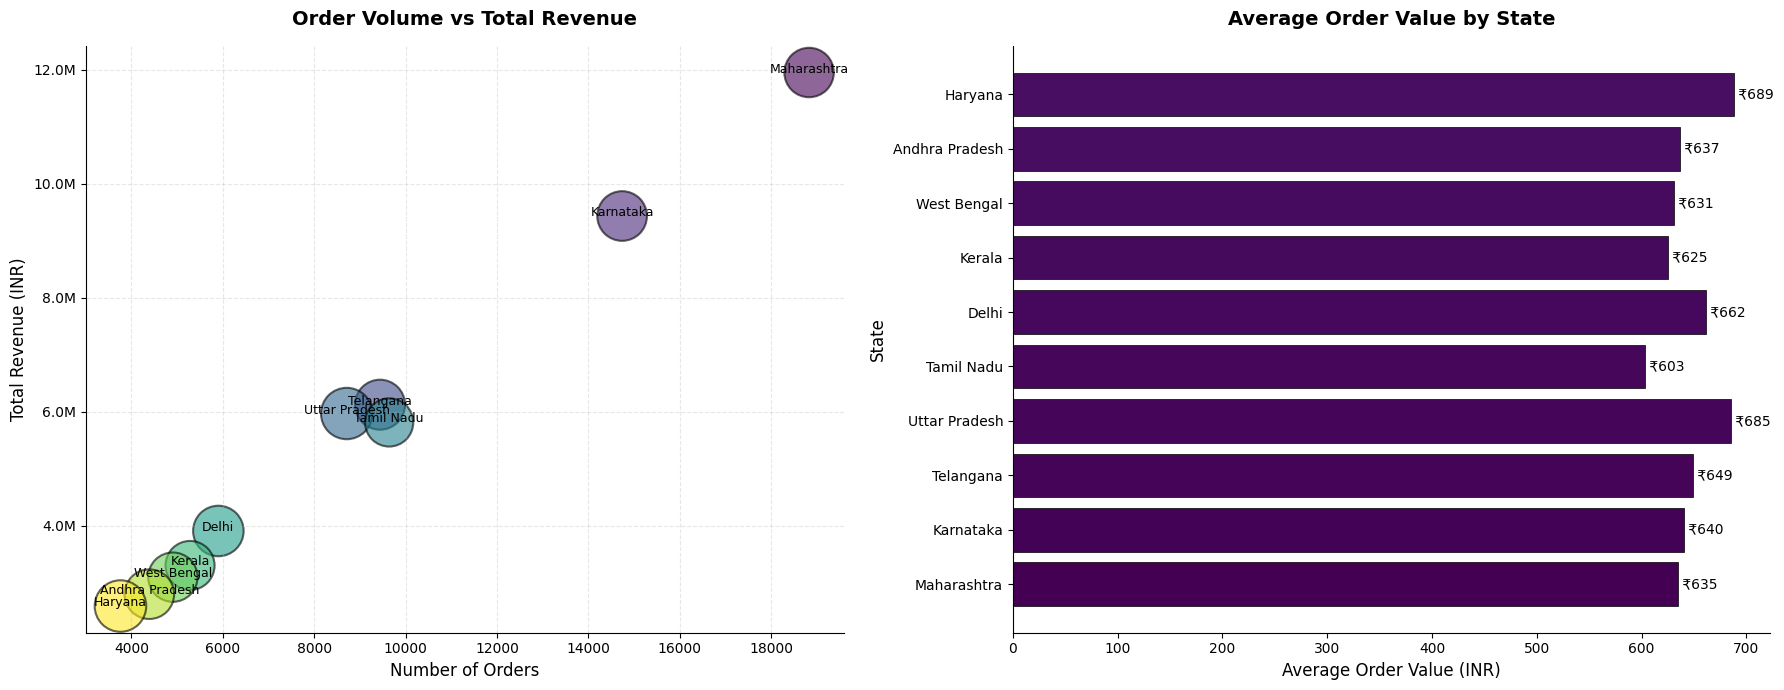


STATE PERFORMANCE METRICS
State                  Total Revenue     Orders Avg Order Value
--------------------------------------------------------------------------------
Maharashtra          ₹    11,955,492     18,833 ₹           635
Karnataka            ₹     9,436,223     14,740 ₹           640
Telangana            ₹     6,123,778      9,441 ₹           649
Uttar Pradesh        ₹     5,968,983      8,712 ₹           685
Tamil Nadu           ₹     5,812,085      9,641 ₹           603
Delhi                ₹     3,906,778      5,903 ₹           662
Kerala               ₹     3,301,081      5,283 ₹           625
West Bengal          ₹     3,096,107      4,907 ₹           631
Andhra Pradesh       ₹     2,796,932      4,392 ₹           637
Haryana              ₹     2,588,923      3,760 ₹           689


In [10]:
# Calculate comprehensive performance metrics including revenue, order count, and average order value
state_metrics = geo_sales_df[geo_sales_df['ship-state'].isin(state_sales.index)].groupby('ship-state').agg({
    'Amount': ['sum', 'count', 'mean']
}).round(2)

state_metrics.columns = ['Total_Revenue', 'Order_Count', 'Avg_Order_Value']
state_metrics = state_metrics.loc[state_sales.index]

# Create scatter plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Scatter plot: Orders vs Revenue
scatter = ax1.scatter(
    state_metrics['Order_Count'], 
    state_metrics['Total_Revenue'],
    s=state_metrics['Avg_Order_Value']*2,
    c=range(len(state_metrics)),
    cmap='viridis',
    alpha=0.6,
    edgecolors='black',
    linewidth=1.5
)

# Add state labels
for idx, state in enumerate(state_metrics.index):
    ax1.annotate(
        state, 
        (state_metrics.loc[state, 'Order_Count'], state_metrics.loc[state, 'Total_Revenue']),
        fontsize=9,
        ha='center'
    )

ax1.set_title('Order Volume vs Total Revenue', fontsize=14, fontweight='bold', pad=15)
ax1.set_xlabel('Number of Orders', fontsize=12)
ax1.set_ylabel('Total Revenue (INR)', fontsize=12)
ax1.yaxis.set_major_formatter(formatter)
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)

# Bar chart: Average Order Value
colors = plt.cm.viridis(range(len(state_metrics)))
bars = ax2.barh(
    state_metrics.index,
    state_metrics['Avg_Order_Value'],
    color=colors,
    edgecolor='black',
    linewidth=0.5
)

# Add value labels
for i, (idx, row) in enumerate(state_metrics.iterrows()):
    ax2.text(
        row['Avg_Order_Value'], 
        i, 
        f' ₹{row["Avg_Order_Value"]:,.0f}',
        va='center',
        fontsize=10
    )

ax2.set_title('Average Order Value by State', fontsize=14, fontweight='bold', pad=15)
ax2.set_xlabel('Average Order Value (INR)', fontsize=12)
ax2.set_ylabel('State', fontsize=12)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig('../images/01_top10_states_sales/order_volume_vs_revenue.png', dpi=300, bbox_inches='tight')
plt.show()

# Print detailed metrics
print("\n" + "="*80)
print("STATE PERFORMANCE METRICS")
print("="*80)
print(f"{'State':<20} {'Total Revenue':>15} {'Orders':>10} {'Avg Order Value':>15}")
print("-"*80)
for state in state_metrics.index:
    print(f"{state:<20} ₹{state_metrics.loc[state, 'Total_Revenue']:>14,.0f} "
          f"{state_metrics.loc[state, 'Order_Count']:>10,.0f} "
          f"₹{state_metrics.loc[state, 'Avg_Order_Value']:>14,.0f}")